# Stage 2 - TF 

Loaded 19 logged steps, shape per step: 28 layers × 1023 slots
Optimizer steps logged: [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540]


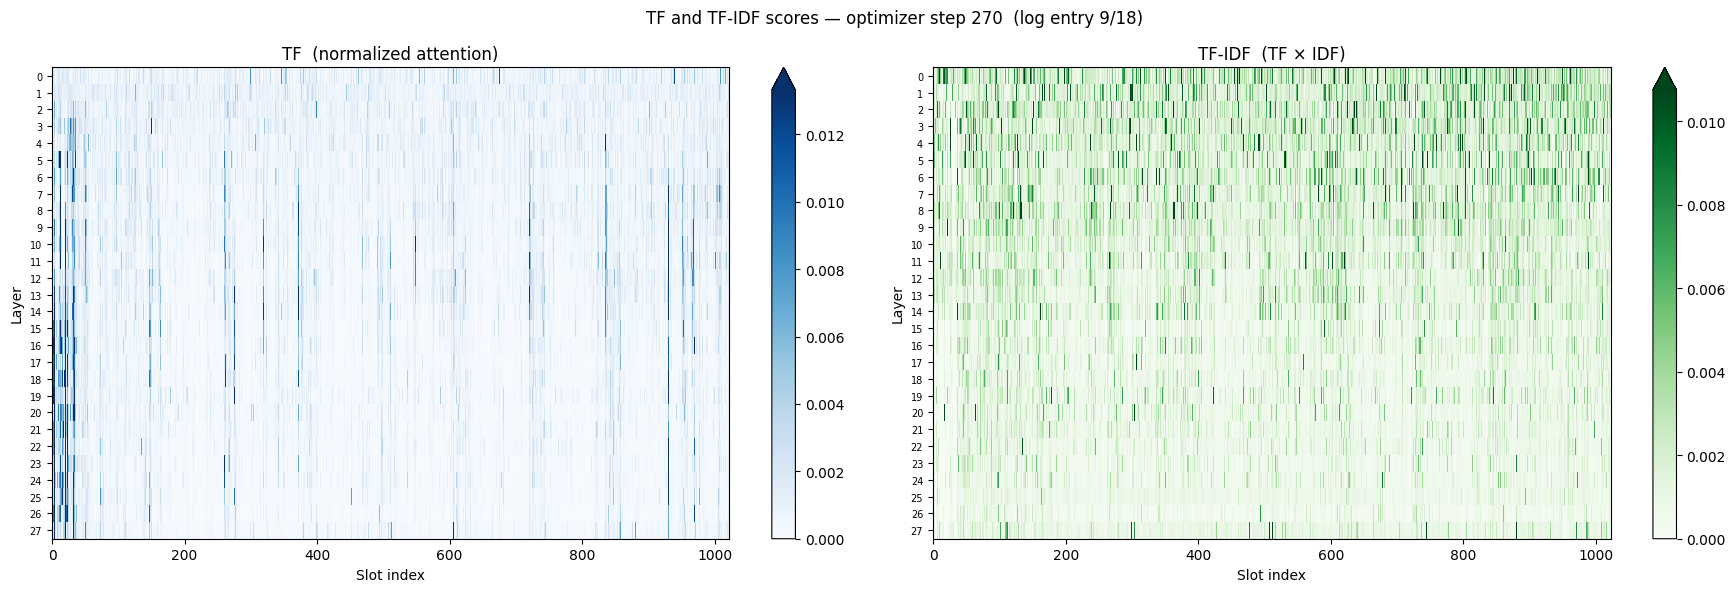

Saved: plot1_step9_heatmap.png


In [9]:
"""
Jupyter Cell 1: Setup, Data Loading, and Single-step Heatmap
"""
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Config ────────────────────────────────────────────────────────────────────
PATH = (
    "/home/vo43/cartridges/outputs/"
    "2026-06-13-14-40-21-continual/"
    "32c0b742-e17c-4790-927b-3a8b4a3505ab/"
    "tfidf_ranking_log.pt"
)

# ── Zoom controls (apply to both plot types) ──────────────────────────────────
layer_range = None   # e.g. (0, 8)  → layers 0-7   | None = all
slot_range  = None   # e.g. (0, 256) → slots 0-255  | None = all

# ── Plot 1 controls ───────────────────────────────────────────────────────────
step_idx = 9   # index into per_step_info list (not the optimizer step number)

# ── Load Data ─────────────────────────────────────────────────────────────────
log = torch.load(PATH, map_location="cpu")
steps = log["per_step_info"]
n_steps = len(steps)
n_layers, n_slots = steps[0]["tf"].shape

print(f"Loaded {n_steps} logged steps, shape per step: {n_layers} layers × {n_slots} slots")
print(f"Optimizer steps logged: {[s['step'] for s in steps]}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def apply_zoom(tensor):
    """Slice [n_layers, n_slots] tensor according to layer_range / slot_range."""
    ls = layer_range[0] if layer_range else 0
    le = min(layer_range[1], n_layers) if layer_range else n_layers
    ss = slot_range[0] if slot_range else 0
    se = min(slot_range[1], n_slots) if slot_range else n_slots
    return tensor[ls:le, ss:se].float(), ls, le, ss, se

def layer_labels(ls, le):
    return list(range(ls, le))

def slot_tick_fmt(ss):
    return ticker.FuncFormatter(lambda x, _: str(int(x + ss)))

# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — single-step heatmap (TF  |  TF-IDF)
# ══════════════════════════════════════════════════════════════════════════════
info = steps[step_idx]
opt_step = info["step"]

tf_view,     ls, le, ss, se = apply_zoom(info["tf"])
tfidf_view, *_              = apply_zoom(info["tfidf"])

layers_shown = layer_labels(ls, le)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f"TF and TF-IDF scores — optimizer step {opt_step}  "
             f"(log entry {step_idx}/{n_steps-1})", fontsize=12)

for ax, data, title, cmap in zip(
    axes,
    [tf_view, tfidf_view],
    ["TF  (normalized attention)", "TF-IDF  (TF × IDF)"],
    ["Blues", "Greens"],
):
    # Clip negative values (artefacts from IDF with zero-freq slots)
    data_plot = data.clamp(min=0).numpy()
    vmax = float(np.percentile(data_plot[data_plot > 0], 99.5)) if (data_plot > 0).any() else data_plot.max()
    im = ax.imshow(data_plot, aspect="auto", interpolation="nearest", cmap=cmap,
                   vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, extend="max")
    ax.set_title(title)
    ax.set_xlabel("Slot index")
    ax.set_ylabel("Layer")
    ax.set_yticks(range(len(layers_shown)))
    ax.set_yticklabels(layers_shown, fontsize=7)
    ax.xaxis.set_major_formatter(slot_tick_fmt(ss))

plt.tight_layout()
plt.savefig(f"plot1_step{step_idx}_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plot1_step{step_idx}_heatmap.png")

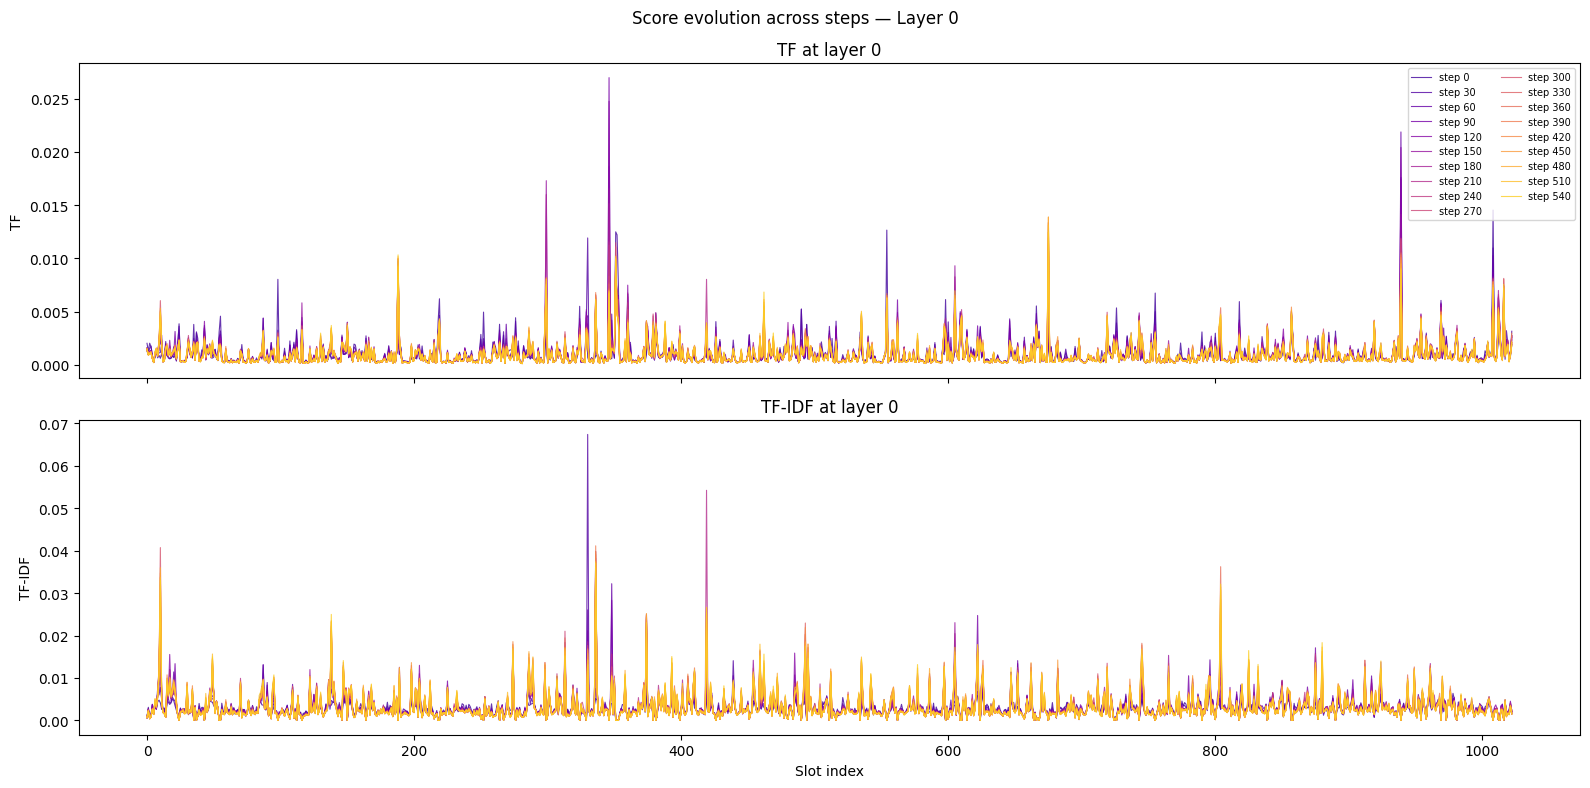

Saved: plot2_layer0_multistep.png


In [2]:
"""
Jupyter Cell 2: Multi-step Comparison
(Run Cell 1 first to load data and helper functions)
"""

# ── Plot 2 controls ───────────────────────────────────────────────────────────
# Choose ONE of the two modes by setting the other to None.
compare_layer = 0    # show score vector (over slots) for this layer, across steps
compare_slot  = None # show score vector (over layers) for this slot, across steps

# Which steps to compare; None = all logged steps (can be slow if many)
step_indices  = None  # e.g. [0, 5, 10, -1]

# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — multi-step comparison
# ══════════════════════════════════════════════════════════════════════════════
chosen_indices = step_indices if step_indices is not None else list(range(n_steps))
chosen_indices = [i % n_steps for i in chosen_indices]   # support negative indexing

if compare_layer is not None and compare_slot is None:
    # ── mode A: fixed layer, x = slot, lines = steps ─────────────────────────
    ss = slot_range[0] if slot_range else 0
    se = min(slot_range[1], n_slots) if slot_range else n_slots
    x  = np.arange(ss, se)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f"Score evolution across steps — Layer {compare_layer}", fontsize=12)

    cmap_steps = plt.cm.plasma(np.linspace(0.1, 0.9, len(chosen_indices)))

    for ax, score_key, ylabel in zip(axes, ["tf", "tfidf"], ["TF", "TF-IDF"]):
        for color, sidx in zip(cmap_steps, chosen_indices):
            s = steps[sidx]
            vec = s[score_key][compare_layer, ss:se].float().clamp(min=0).numpy()
            ax.plot(x, vec, color=color, linewidth=0.8, alpha=0.8,
                    label=f"step {s['step']}")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} at layer {compare_layer}")

    axes[-1].set_xlabel("Slot index")
    handles, labels = axes[0].get_legend_handles_labels()
    # show at most 10 legend entries to keep it readable
    step = max(1, len(handles) // 10)
    axes[0].legend(handles[::step], labels[::step], fontsize=7,
                   loc="upper right", ncol=2)

    plt.tight_layout()
    fname = f"plot2_layer{compare_layer}_multistep.png"

elif compare_slot is not None and compare_layer is None:
    # ── mode B: fixed slot, x = layer, lines = steps ─────────────────────────
    ls = layer_range[0] if layer_range else 0
    le = min(layer_range[1], n_layers) if layer_range else n_layers
    x  = np.arange(ls, le)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Score evolution across steps — Slot {compare_slot}", fontsize=12)

    cmap_steps = plt.cm.plasma(np.linspace(0.1, 0.9, len(chosen_indices)))

    for ax, score_key, ylabel in zip(axes, ["tf", "tfidf"], ["TF", "TF-IDF"]):
        for color, sidx in zip(cmap_steps, chosen_indices):
            s = steps[sidx]
            vec = s[score_key][ls:le, compare_slot].float().clamp(min=0).numpy()
            ax.plot(x, vec, color=color, linewidth=1.2, alpha=0.8, marker="o",
                    markersize=3, label=f"step {s['step']}")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} at slot {compare_slot}")

    axes[-1].set_xlabel("Layer")
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(x, fontsize=7)
    handles, labels = axes[0].get_legend_handles_labels()
    step = max(1, len(handles) // 10)
    axes[0].legend(handles[::step], labels[::step], fontsize=7,
                   loc="upper right", ncol=2)

    plt.tight_layout()
    fname = f"plot2_slot{compare_slot}_multistep.png"

else:
    raise ValueError("Set exactly one of compare_layer or compare_slot (not both, not neither).")

plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

# Stage 1 - Document Frequency

In [1]:
path = "/home/vo43/cartridges/outputs/2026-06-13-14-40-21-continual/32c0b742-e17c-4790-927b-3a8b4a3505ab/tfidf_ranking_log.pt"

import torch
tfidf_ranking_log = torch.load(path, map_location='cpu')

In [2]:
tfidf_ranking_log.keys()

dict_keys(['idf', 'document_frequencies', 'num_background_batches', 'use_idf', 'granularity', 'per_step_info'])

In [ ]:
# tfidf_ranking_log['num_background_batches'] # -> 855
# tfidf_ranking_log['document_frequencies'].shape # -> [28, 1023]
tfidf_ranking_log['document_frequencies']

tensor([[540,  77, 584,  ...,   6,  25, 388],
        [844,  32,   0,  ..., 149,  19,  35],
        [855, 854,   0,  ...,  21,  15, 115],
        ...,
        [855, 845, 841,  ...,  75,   3, 855],
        [855, 846, 837,  ..., 180,  20, 855],
        [855, 855, 617,  ...,  92,  81, 855]])

In [18]:
tfidf_ranking_log['per_step_info'][0]

{'step': 0,
 'tf': tensor([[2.0186e-03, 1.2904e-03, 2.0282e-03,  ..., 4.1362e-04, 7.6654e-04,
          1.9042e-03],
         [3.8101e-03, 9.3626e-04, 1.3721e-04,  ..., 1.3558e-03, 6.6134e-04,
          8.9709e-04],
         [1.5627e-02, 1.0277e-02, 1.7274e-04,  ..., 8.2774e-04, 6.1565e-04,
          1.4217e-03],
         ...,
         [2.8215e-01, 3.7394e-03, 2.8365e-03,  ..., 3.2663e-04, 1.4625e-04,
          2.6966e-02],
         [3.7191e-01, 6.6063e-03, 3.8411e-03,  ..., 4.0425e-04, 1.2862e-04,
          5.1166e-02],
         [2.4445e-01, 2.1190e-02, 1.2235e-03,  ..., 5.9273e-04, 4.5683e-04,
          3.4698e-02]]),
 'tfidf': tensor([[ 9.2622e-04,  3.0913e-03,  7.7206e-04,  ...,  1.9880e-03,
           2.6784e-03,  1.5018e-03],
         [ 4.9278e-05,  3.0482e-03,  9.2651e-04,  ...,  2.3613e-03,
           2.4843e-03,  2.8427e-03],
         [-9.3143e-10,  1.2013e-05,  1.1664e-03,  ...,  3.0306e-03,
           2.4501e-03,  2.8416e-03],
         ...,
         [-1.6817e-08,  4.3942e-05

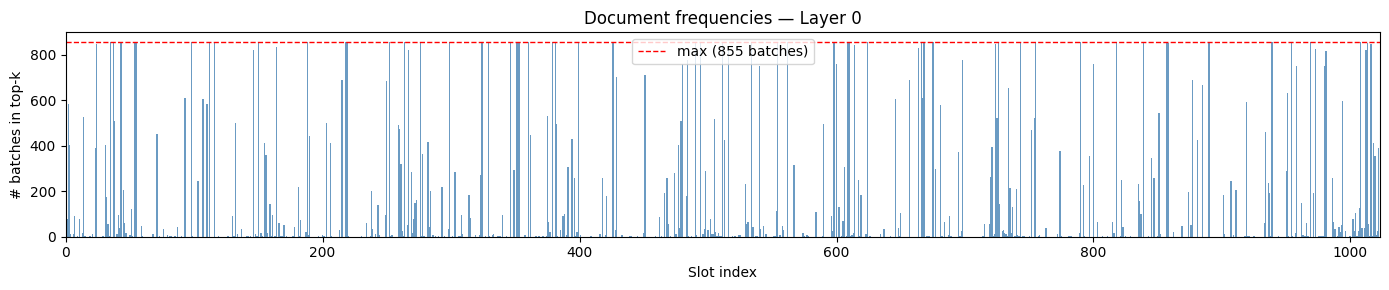

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = tfidf_ranking_log['document_frequencies']  # shape [28, 1023]
n_layers, n_slots = df.shape
num_bg = tfidf_ranking_log['num_background_batches']  # 855

# ── Plot 1: document frequencies at a single layer ──────────────────────────
layer_x = 0  # change this to inspect any layer

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(n_slots), df[layer_x].numpy(), width=1.0, color='steelblue', alpha=0.8)
ax.axhline(num_bg, color='red', linestyle='--', linewidth=1, label=f'max ({num_bg} batches)')
ax.set_xlabel('Slot index')
ax.set_ylabel('# batches in top-k')
ax.set_title(f'Document frequencies — Layer {layer_x}')
ax.set_xlim(0, n_slots)
ax.legend()
plt.tight_layout()
plt.show()

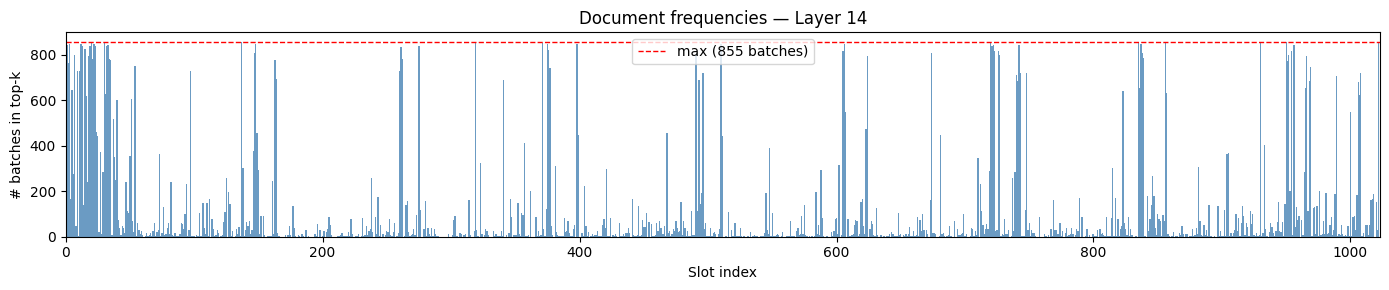

In [25]:
# ── Plot 1: document frequencies at a single layer ──────────────────────────
layer_x = 14  # change this to inspect any layer

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(n_slots), df[layer_x].numpy(), width=1.0, color='steelblue', alpha=0.8)
ax.axhline(num_bg, color='red', linestyle='--', linewidth=1, label=f'max ({num_bg} batches)')
ax.set_xlabel('Slot index')
ax.set_ylabel('# batches in top-k')
ax.set_title(f'Document frequencies — Layer {layer_x}')
ax.set_xlim(0, n_slots)
ax.legend()
plt.tight_layout()
plt.show()

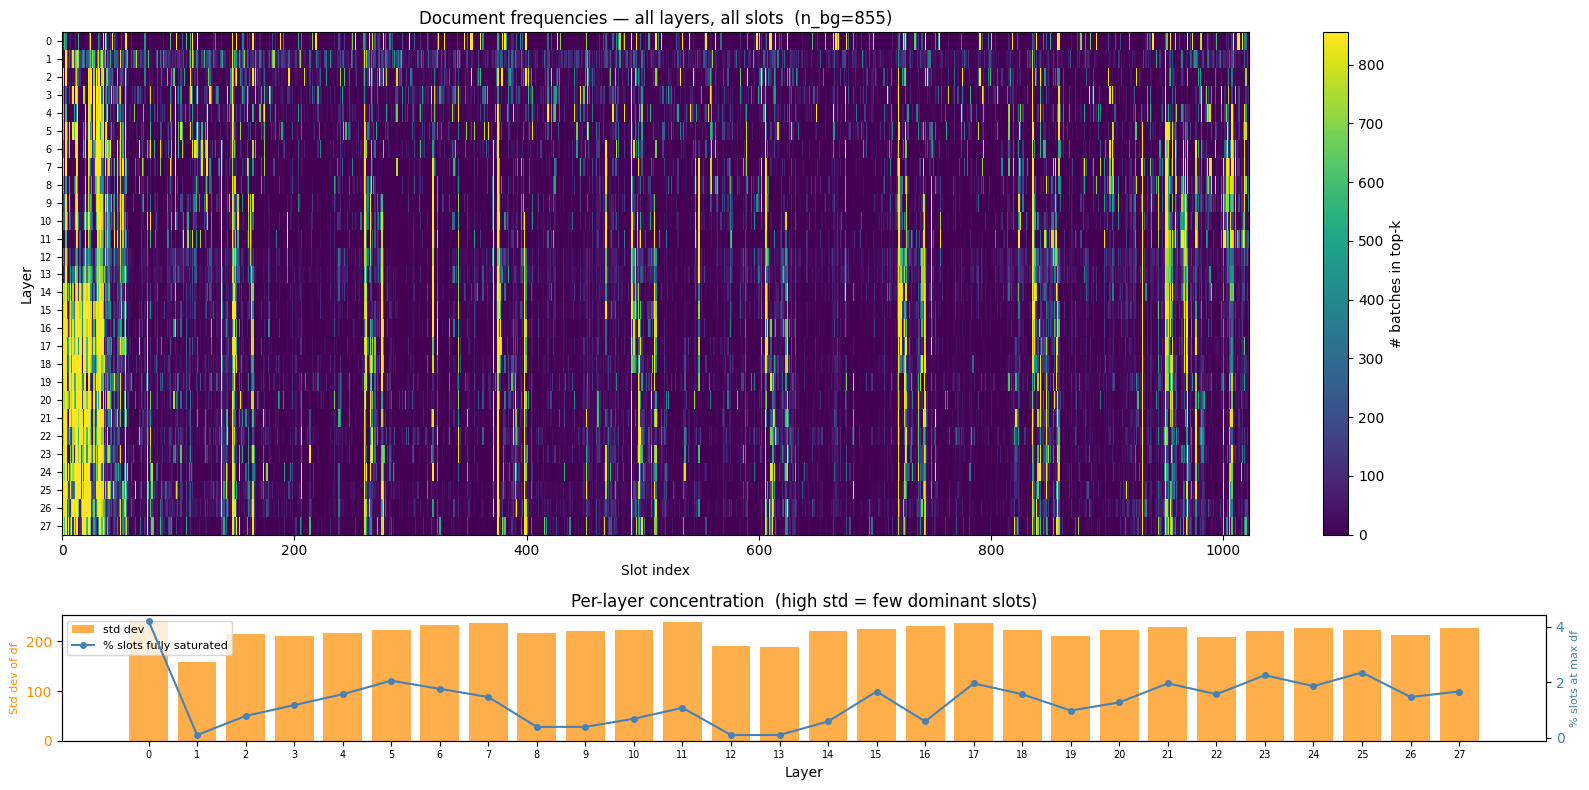

Note: mean df over visible region is 107.0
Std dev range for visible region: 158.0 – 240.6


In [ ]:
import matplotlib.ticker as ticker  # Ensure this is imported for the x-axis formatter
# df : shape [28, 1023]

# ── Plot 2: progression across all layers (heatmap) ─────────────────────────
# Set layer_range to zoom in on a subset, e.g. (0, 8) for layers 0-7.
# Set to None to show all layers.
layer_range = None   # e.g. (0, 8)

# Set slot_range to zoom in on a subset, e.g. (100, 200) for slots 100-199.
# Set to None to show all slots.
slot_range = None # (1000, 1024)    # e.g. (100, 200)

layer_start = layer_range[0] if layer_range else 0
layer_end   = layer_range[1] if layer_range else n_layers

slot_start  = slot_range[0] if slot_range else 0
slot_end    = min(slot_range[1], df.shape[1]) if slot_range else df.shape[1]
if slot_range and slot_range[1] > df.shape[1]:
    print(f"Warning: slot_range end {slot_range[1]} exceeds n_slots={df.shape[1]}, clamped to {df.shape[1]}")

# Slice the dataframe on both dimensions (layers and slots)
df_view      = df[layer_start:layer_end, slot_start:slot_end].float()
layers_shown = list(range(layer_start, layer_end))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [4, 1]})

# -- heatmap: rows = layers, cols = slots
ax = axes[0]
im = ax.imshow(
    df_view.numpy(),
    aspect='auto',
    interpolation='nearest',
    cmap='viridis',
    vmin=0,
    vmax=num_bg,
)
plt.colorbar(im, ax=ax, label='# batches in top-k')

ax.set_xlabel('Slot index')
ax.set_ylabel('Layer')

# Format Y-axis to show actual layer indices
ax.set_yticks(range(len(layers_shown)))
ax.set_yticklabels(layers_shown, fontsize=7)

# Format X-axis to show actual slot indices based on the zoom offset
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x + slot_start)}"))

layer_zoom_str = f'layers {layer_start}\u2013{layer_end-1}' if layer_range else 'all layers'
slot_zoom_str  = f'slots {slot_start}\u2013{slot_end-1}' if slot_range else 'all slots'
ax.set_title(f'Document frequencies \u2014 {layer_zoom_str}, {slot_zoom_str}  (n_bg={num_bg})')

# -- std dev per layer.
# Mean df is always constant (= num_bg * top_k / n_slots) because each batch
# selects exactly top_k slots per layer -- so mean is uninformative.
# Std dev shows concentration: high std = few slots dominate; low = uniform.
# Note: When slot_range is set, these statistics are calculated ONLY for the visible slots.
ax2 = axes[1]
std_per_layer  = df_view.std(dim=1).numpy()
frac_saturated = (df_view >= num_bg).float().mean(dim=1).numpy()

color1, color2 = 'darkorange', 'steelblue'
ax2.bar(layers_shown, std_per_layer, color=color1, alpha=0.7, label='std dev')
ax2_r = ax2.twinx()
ax2_r.plot(layers_shown, frac_saturated * 100, color=color2, marker='o',
           markersize=4, linewidth=1.5, label='% slots fully saturated')
ax2_r.set_ylabel('% slots at max df', color=color2, fontsize=8)
ax2_r.tick_params(axis='y', labelcolor=color2)

ax2.set_xlabel('Layer')
ax2.set_ylabel('Std dev of df', color=color1, fontsize=8)
ax2.set_title('Per-layer concentration  (high std = few dominant slots)')
ax2.set_xticks(layers_shown)
ax2.xaxis.set_tick_params(labelsize=7)
ax2.tick_params(axis='y', labelcolor=color1)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Note: mean df over visible region is {df_view.mean(dim=1).mean():.1f}")
print(f"Std dev range for visible region: {std_per_layer.min():.1f} \u2013 {std_per_layer.max():.1f}")

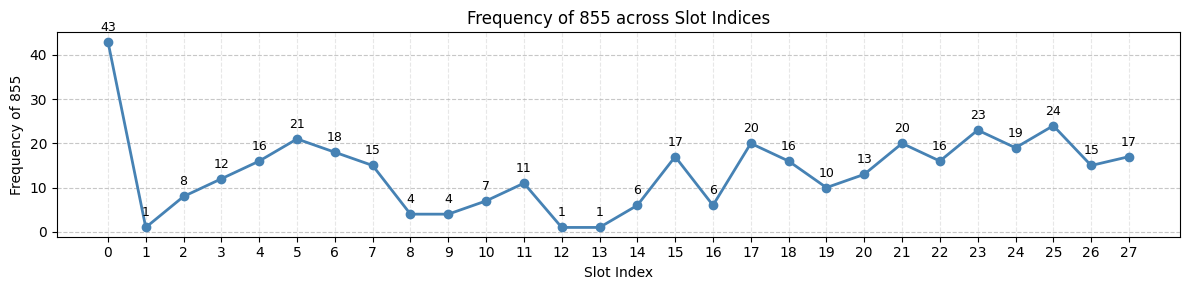

In [22]:
import matplotlib.pyplot as plt

# 1. Generate the x and y data points based on your loop
x_values = list(range(28))
y_values = [int(sum(df[i] == 855)) for i in range(28)]

# 2. Create the line plot
plt.figure(figsize=(12, 3))
plt.plot(x_values, y_values, marker='o', linestyle='-', color='steelblue', linewidth=2)

# 3. Add the numerical value at each point
for x, y in zip(x_values, y_values):
    # textcoords="offset points" lets us push the text slightly above the dot (xytext=(0, 8))
    # ha='center' ensures the number is perfectly centered over the dot
    plt.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

# 4. Add labels, title, and formatting
plt.xlabel('Slot Index', fontsize=10)
plt.ylabel('Frequency of 855', fontsize=10)
plt.title('Frequency of 855 across Slot Indices', fontsize=12)

# Force the x-axis to show every slot index
plt.xticks(x_values)

# Add a light grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)

# 5. Display the graph
plt.tight_layout()
plt.show()